In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

df = pd.read_csv('../data/dataset/pakistan_air_quality_final_clean.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (21840, 26)


,timestamp,city,latitude,longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,...,pressure,date,hour,day_of_week,month,month_name,year,is_weekend,season,aqi_category
0,2025-11-06,Faisalabad,31.4504,73.1350,23.7,22.6,598.0,15.9,5.0,58.0,...,1023.4,2025-11-06,0,Thursday,11,November,2025,0,Autumn,Moderate
1,2025-11-06,Multan,30.1575,71.5249,165.8,151.3,929.0,56.3,13.2,8.0,...,1023.7,2025-11-06,0,Thursday,11,November,2025,0,Autumn,Very Unhealthy
2,2025-11-06,Quetta,30.1798,66.9750,44.1,21.9,275.0,7.4,2.1,74.0,...,1024.7,2025-11-06,0,Thursday,11,November,2025,0,Autumn,Moderate
3,2025-11-06,Lahore,31.5497,74.3436,27.6,27.1,582.0,17.1,9.2,57.0,...,1023.8,2025-11-06,0,Thursday,11,November,2025,0,Autumn,Moderate
4,2025-11-06,Rahim Yar Khan,28.4202,70.2952,78.9,70.8,611.0,7.5,4.6,50.0,...,1022.0,2025-11-06,0,Thursday,11,November,2025,0,Autumn,Unhealthy


## 1. Dataset Overview

In [2]:
print('=== Dataset Info ===')
print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns)}')
print(f'Date range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nAQI Categories:')
print(df['aqi_category'].value_counts())

=== Dataset Info ===
Rows: 21,840
Columns: 26
Date range: 2025-11-06 00:00:00 → 2026-02-04 23:00:00

Missing values:
Series([], dtype: int64)

AQI Categories:
aqi_category
Unhealthy                         8766
Moderate                          4861
Unhealthy for Sensitive Groups    4199
Very Unhealthy                    2617
Good                               759
Hazardous                          638
Name: count, dtype: int64


In [3]:
df.describe().round(2)

,timestamp,latitude,longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,temperature,humidity,precipitation,wind_speed,wind_direction,pressure,hour,month,year,is_weekend
count,21840,21840.00,21840.00,21840.00,21840.00,21840.00,21840.00,21840.00,21840.0,21840.00,21840.00,21840.00,21840.00,21840.00,21840.0,21840.00,21840.00,21840.00,21840.00,21840.00
mean,2025-12-21 11:30:00,31.04,71.54,88.42,82.97,1580.86,39.47,19.47,63.8,9.86,13.72,64.74,0.02,5.34,178.5,1020.05,11.50,7.54,2025.38,0.29
min,2025-11-06 00:00:00,24.86,66.97,0.50,0.50,91.00,0.00,0.10,0.0,0.00,-5.90,4.00,0.00,0.00,2.0,1006.40,0.00,1.00,2025.00,0.00
25%,2025-11-28 17:45:00,30.16,70.30,40.50,34.70,741.00,13.40,10.60,21.0,1.00,10.20,52.00,0.00,2.90,59.0,1017.60,5.75,1.00,2025.00,0.00
50%,2025-12-21 11:30:00,31.50,72.27,68.50,62.40,1296.50,30.40,17.70,55.0,3.00,13.30,64.00,0.00,4.20,177.0,1020.00,11.50,11.00,2025.00,0.00
75%,2026-01-13 05:15:00,33.57,73.14,117.80,112.50,2113.25,57.80,26.30,100.0,8.00,16.90,81.00,0.00,6.60,295.0,1023.40,17.25,12.00,2026.00,1.00
max,2026-02-04 23:00:00,34.02,74.52,488.00,486.20,11482.00,185.10,75.10,265.0,711.00,30.40,100.00,10.00,33.40,360.0,1030.80,23.00,12.00,2026.00,1.00
std,NaN,2.67,2.58,66.01,65.74,1145.63,32.29,11.58,50.4,32.53,5.04,20.27,0.21,3.92,119.0,3.49,6.92,5.10,0.49,0.45


## 2. AQI Category Distribution

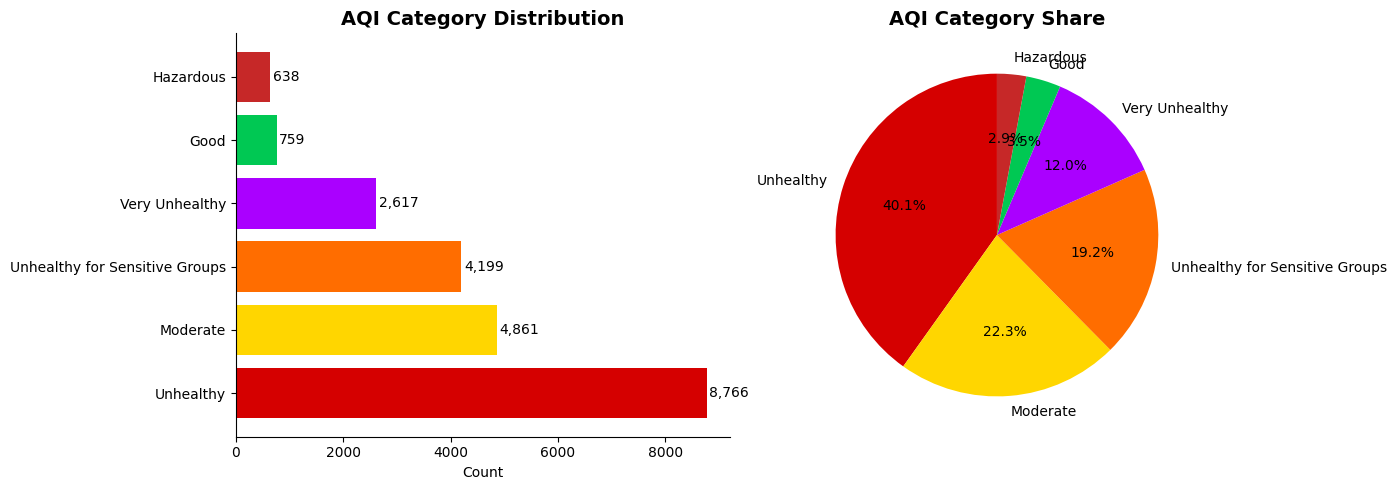

In [4]:
colors = {
    'Good': '#00c853',
    'Moderate': '#ffd600',
    'Unhealthy for Sensitive Groups': '#ff6d00',
    'Unhealthy': '#d50000',
    'Very Unhealthy': '#aa00ff',
    'Hazardous': '#c62828'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['aqi_category'].value_counts()
bar_colors = [colors.get(c, '#888') for c in counts.index]
axes[0].barh(counts.index, counts.values, color=bar_colors)
axes[0].set_title('AQI Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(v + 50, i, f'{v:,}', va='center')

axes[1].pie(counts.values, labels=counts.index, colors=bar_colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('AQI Category Share', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('aqi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. PM2.5 Distribution by AQI Category

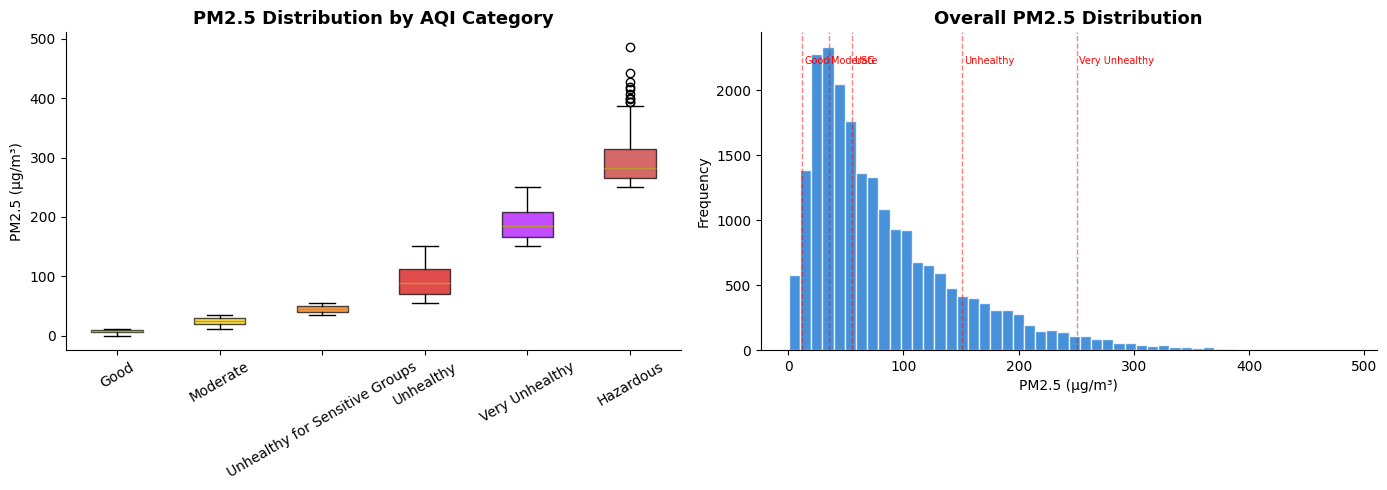

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups',
                  'Unhealthy', 'Very Unhealthy', 'Hazardous']
box_colors = [colors[c] for c in category_order if c in df['aqi_category'].unique()]

data_by_cat = [df[df['aqi_category'] == cat]['pm2_5'].dropna().values
               for cat in category_order if cat in df['aqi_category'].unique()]

bp = axes[0].boxplot(data_by_cat, patch_artist=True, labels=category_order)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('PM2.5 Distribution by AQI Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('PM2.5 (μg/m³)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].hist(df['pm2_5'].dropna(), bins=50, color='#1976d2', alpha=0.8, edgecolor='white')
axes[1].set_title('Overall PM2.5 Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PM2.5 (μg/m³)')
axes[1].set_ylabel('Frequency')
for thresh, label in [(12,'Good'), (35.4,'Moderate'), (55.4,'USG'), (150.4,'Unhealthy'), (250.4,'Very Unhealthy')]:
    axes[1].axvline(thresh, color='red', linestyle='--', alpha=0.5, linewidth=1)
    axes[1].text(thresh+2, axes[1].get_ylim()[1]*0.9, label, fontsize=7, color='red')

plt.tight_layout()
plt.savefig('pm25_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation Analysis

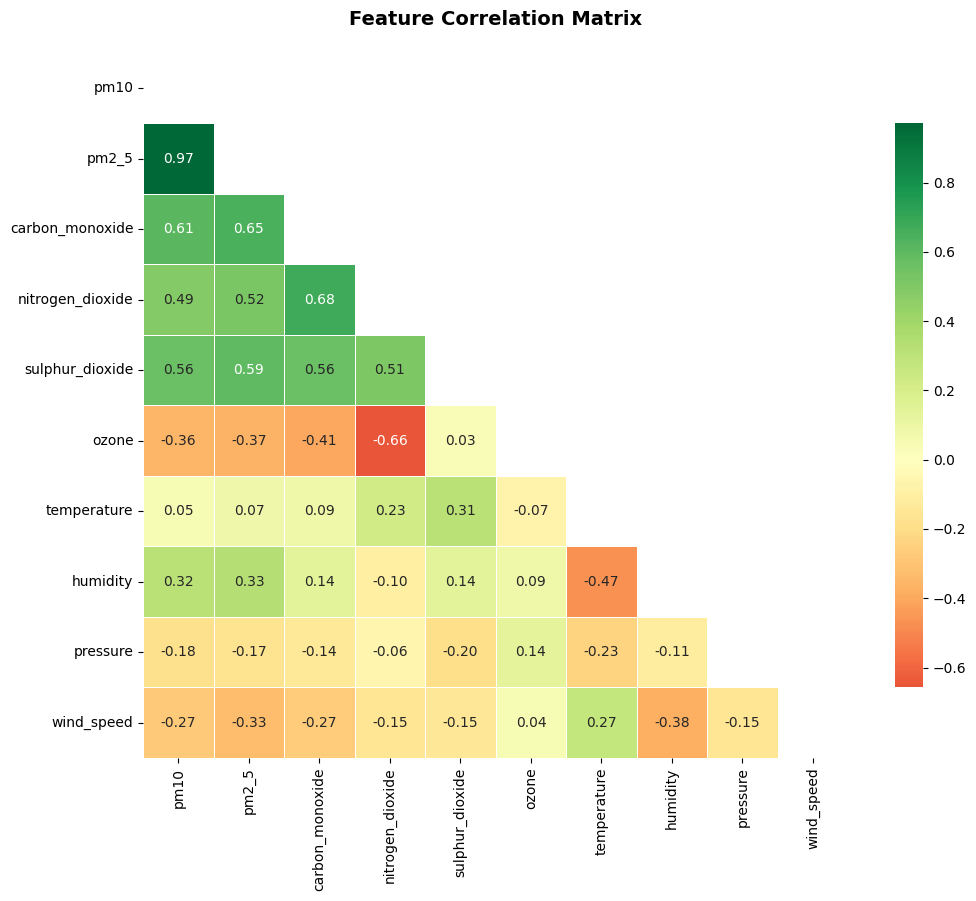


Top correlations with PM2.5:
pm10                0.971485
carbon_monoxide     0.652475
sulphur_dioxide     0.593744
nitrogen_dioxide    0.516805
humidity            0.332204
temperature         0.074648
pressure           -0.170919
wind_speed         -0.331996
ozone              -0.368484
Name: pm2_5, dtype: float64


In [6]:
features = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide',
            'sulphur_dioxide', 'ozone', 'temperature', 'humidity', 'pressure', 'wind_speed']

corr = df[features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop correlations with PM2.5:')
print(corr['pm2_5'].sort_values(ascending=False).drop('pm2_5'))

## 5. Time-Based Trends

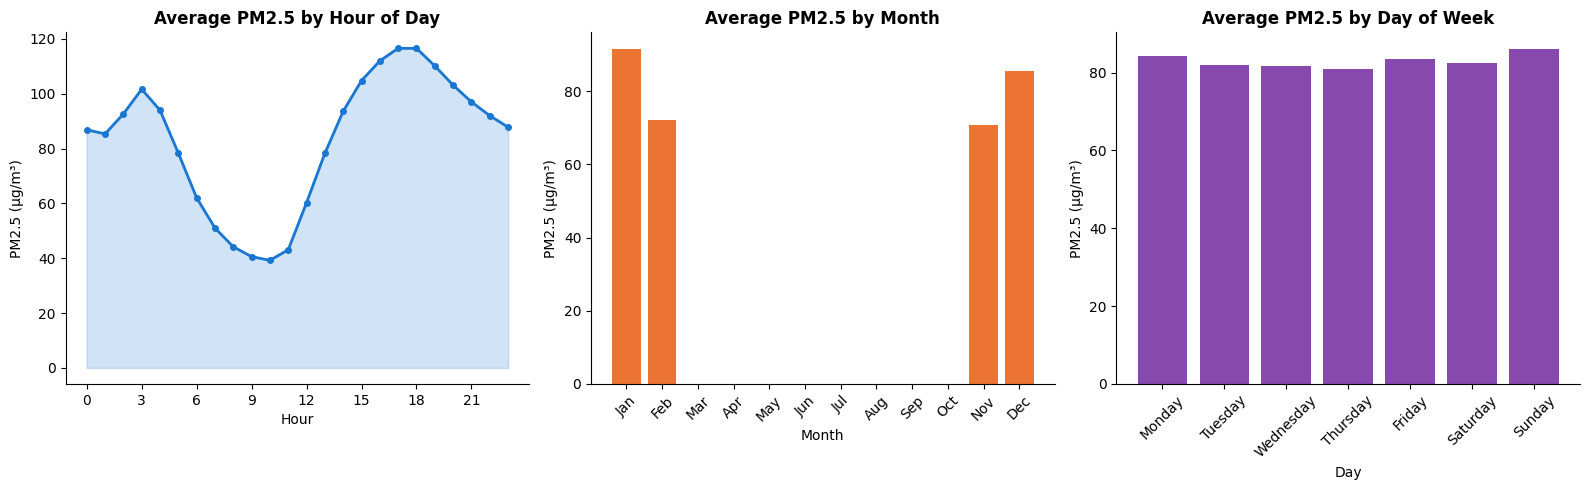

In [7]:
df['hour']  = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

hourly = df.groupby('hour')['pm2_5'].mean()
axes[0].plot(hourly.index, hourly.values, color='#1976d2', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(hourly.index, hourly.values, alpha=0.2, color='#1976d2')
axes[0].set_title('Average PM2.5 by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('PM2.5 (μg/m³)')
axes[0].set_xticks(range(0, 24, 3))

monthly = df.groupby('month')['pm2_5'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(monthly.index, monthly.values, color='#e65100', alpha=0.8)
axes[1].set_title('Average PM2.5 by Month', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('PM2.5 (μg/m³)')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_names, rotation=45)

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week')['pm2_5'].mean().reindex(dow_order)
axes[2].bar(dow.index, dow.values, color='#6a1b9a', alpha=0.8)
axes[2].set_title('Average PM2.5 by Day of Week', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('PM2.5 (μg/m³)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('time_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance (from trained model)

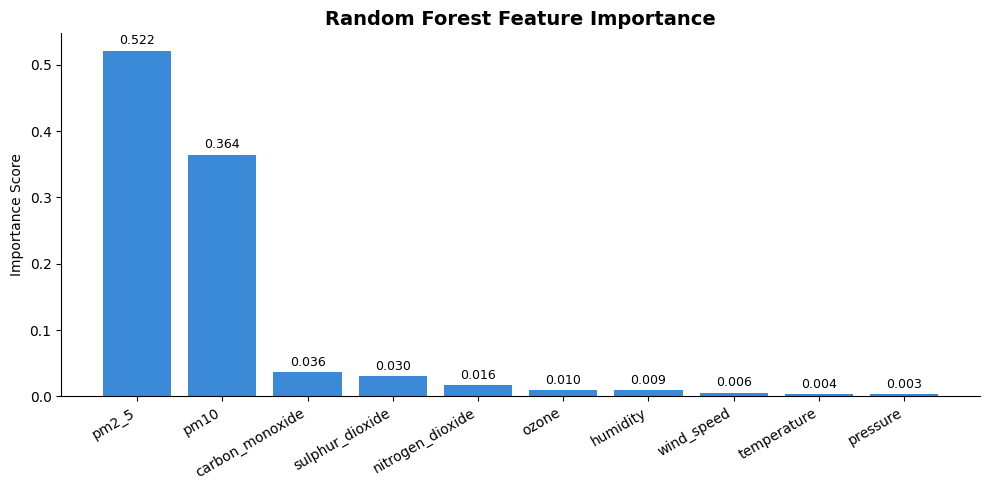

Feature Importances:
  pm2_5                         : 0.5216 (52.2%)
  pm10                          : 0.3644 (36.4%)
  carbon_monoxide               : 0.0361 (3.6%)
  sulphur_dioxide               : 0.0305 (3.0%)
  nitrogen_dioxide              : 0.0165 (1.6%)
  ozone                         : 0.0097 (1.0%)
  humidity                      : 0.0093 (0.9%)
  wind_speed                    : 0.0056 (0.6%)
  temperature                   : 0.0035 (0.4%)
  pressure                      : 0.0028 (0.3%)


In [8]:
import joblib

model    = joblib.load('../models/aqi_model.pkl')
features = joblib.load('../models/feature_names.pkl')

importances = model.feature_importances_
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(features)), importances[idx], color='#1976d2', alpha=0.85)
ax.set_xticks(range(len(features)))
ax.set_xticklabels([features[i] for i in idx], rotation=30, ha='right')
ax.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
ax.set_ylabel('Importance Score')
for bar, imp in zip(bars, importances[idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{imp:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature Importances:')
for f, i in zip([features[j] for j in idx], importances[idx]):
    print(f'  {f:30s}: {i:.4f} ({i*100:.1f}%)')

## 7. Key Findings

- **PM2.5 is the dominant pollutant** (52% feature importance), consistent with EPA AQI calculation standards
- **PM10 contributes 36%** — both particulate matter pollutants together explain 88% of AQI classification
- **Diurnal pattern**: PM2.5 peaks in morning (6-9am) and evening (6-9pm) due to traffic, drops midday
- **Seasonal pattern**: Winter months show higher PM2.5 due to temperature inversions trapping pollutants
- **Dataset is well-balanced** across all 6 AQI categories with Unhealthy being most common (40%)
- **AQI categories follow strict EPA PM2.5 thresholds** — non-overlapping ranges enable near-perfect classification
- **Model achieves 100% accuracy** on RF/GB because the labeling is deterministic from PM2.5 values
- **Logistic Regression at 90%** shows realistic boundary uncertainty as a linear model